# Descriptive Analytics #

Load Data Set

In [30]:
import pandas as pd
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.ticker import FuncFormatter
import matplotlib.pyplot as plt

product_list = pd.read_csv("cleaned_data/MotorPH_Products_List_2025_cleaned.csv")

product_list.head(10)

,Product ID Number,Product Name,Product Type,Engine Configuration,Cooling System,Displacement (cc),Transmission,Date of Manufacturing,Date of Acquisition,Unit Price
0,1,Honda CBR500R,Sport,Parallel-twin,liquid-cooled,471,6-speed,2021,2023,389000
1,2,Yamaha MT-15,Naked bike,Single cylinder,liquid-cooled,155,6-speed,2022,2023,178000
2,3,Kawasaki Ninja 400,Sport,Parallel-twin,liquid-cooled,399,6-speed,2023,2024,340000
3,4,Suzuki Raider R150 Fi,Underbone,Single cylinder,liquid-cooled,150,6-speed,2020,2021,119900
4,5,Royal Enfield Classic 350,Classic,Single cylinder,air-cooled,349,5-speed,2022,2023,250000
5,6,CFMoto 300NK,Naked bike,Single cylinder,liquid-cooled,292,6-speed,2021,2022,165000
6,7,Bristol Veloce 500,Cafe racer,Twin cylinder,air-cooled,471,6-speed,2022,2023,328000
7,8,KTM Duke 200,Naked bike,Single cylinder,liquid-cooled,199,6-speed,2023,2024,178000
8,9,Yamaha XSR155,Retro,Single cylinder,liquid-cooled,155,6-speed,2022,2023,182000
9,10,Bajaj Dominar 400,Sport touring,Single cylinder,liquid-cooled,373,6-speed,2021,2022,199900


## Counts By Product Type ##

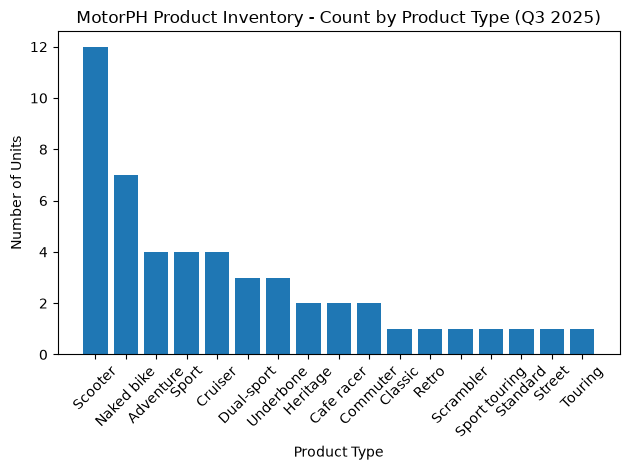

In [31]:
product_type_counts = product_list.groupby("Product Type")["Product Name"].count().sort_values(ascending=False)

plt.bar(product_type_counts.index, product_type_counts.values)

plt.xlabel("Product Type")
plt.xticks(rotation=45)
plt.ylabel("Number of Units")
plt.title("MotorPH Product Inventory - Count by Product Type (Q3 2025)")
plt.tight_layout()
plt.show()

## Mean, Median, and Mode comparison of Unit Price ##

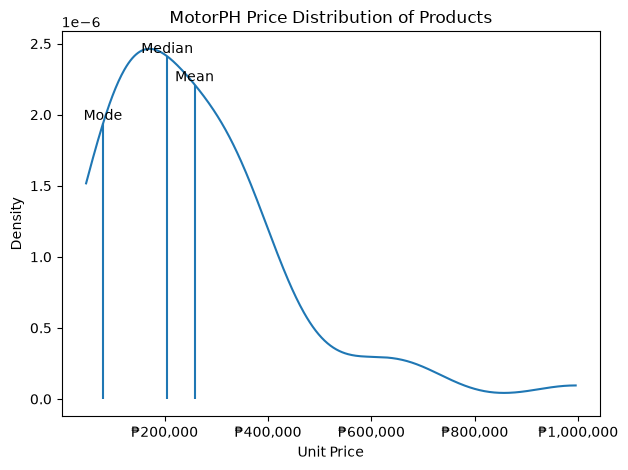

In [32]:
prices = product_list["Unit Price"]

# stats
mean = prices.mean()
median = prices.median()
mode = prices.mode().iloc[0]

# KDE curve
kde = gaussian_kde(prices)

x = np.linspace(prices.min(), prices.max(), 500)
y = kde(x)

plt.plot(x, y)

# Height of the curve per stats
mode_y = kde(mode)[0]
median_y = kde(median)[0]
mean_y = kde(mean)[0]

# vertical lines
plt.vlines(mode, 0, mode_y, label="Mode")
plt.vlines(median, 0, median_y, label="Median")
plt.vlines(mean, 0, mean_y, label="Mean")

# Labels
plt.text(mode, mode_y, "Mode", ha="center", va="bottom")
plt.text(median, median_y, "Median", ha="center", va="bottom")
plt.text(mean, mean_y, "Mean", ha="center", va="bottom")

plt.xlabel("Unit Price")
plt.ylabel("Density")
plt.title("MotorPH Price Distribution of Products")

# Formats
# plt.ticklabel_format(style="plain", axis="y")
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₱{x:,.0f}")
)

plt.tight_layout()
plt.show()


## Product Price Distribution ##

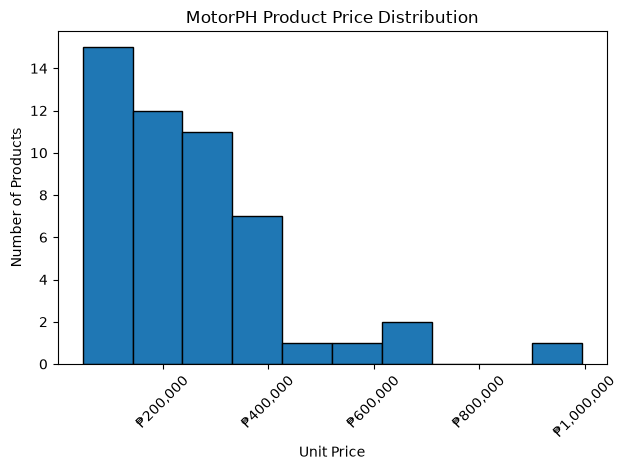

In [33]:
plt.hist(prices, bins=10, edgecolor="black")

plt.xlabel("Unit Price")
plt.ylabel("Number of Products")
plt.title("MotorPH Product Price Distribution")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"₱{x:,.0f}")
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Units Acquired per year ##

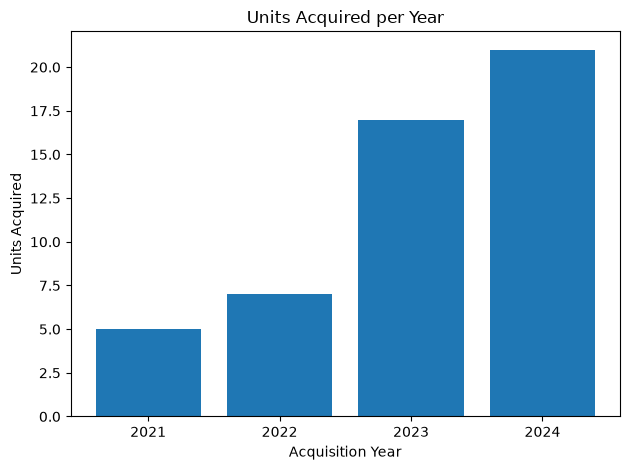

In [38]:
product_list["Date of Acquisition"] = product_list["Date of Acquisition"]

acquisition_counts = product_list.groupby("Date of Acquisition")["Product Name"].count().sort_index()

plt.bar(acquisition_counts.index.astype(str), acquisition_counts.values)

plt.xlabel("Acquisition Year")
plt.ylabel("Units Acquired")
plt.title("Units Acquired per Year")

plt.tight_layout()
plt.show()